In [ ]:
#experiment-5=> edge detection using sobel operator

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
image = cv2.imread("giraffe.jpg", cv2.IMREAD_GRAYSCALE)

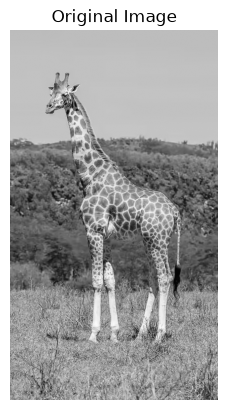

In [5]:
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [7]:
def sobel_filter(image):

    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])

    sobel_y = np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ])

    rows, cols = image.shape

    padded = np.pad(image, 1, mode='constant')

    gx = np.zeros((rows, cols), dtype=np.float32)
    gy = np.zeros((rows, cols), dtype=np.float32)
    output = np.zeros((rows, cols), dtype=np.float32)

    for i in range(rows):
        for j in range(cols):

            sum_x = 0
            sum_y = 0

            for m in range(3):
                for n in range(3):

                    pixel = float(padded[i+m][j+n])

                    sum_x += pixel * sobel_x[m][n]
                    sum_y += pixel * sobel_y[m][n]

            gx[i][j] = sum_x
            gy[i][j] = sum_y

            output[i][j] = np.sqrt(sum_x**2 + sum_y**2)

    output = np.clip(output, 0, 255)

    return gx, gy, output.astype(np.uint8)

In [8]:
gx, gy, edge_image = sobel_filter(image)

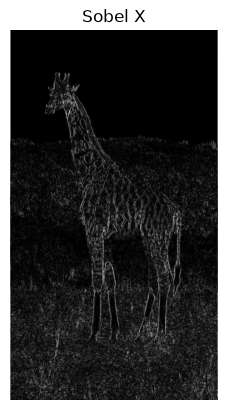

In [9]:
plt.imshow(np.abs(gx), cmap="gray")
plt.title("Sobel X")
plt.axis("off")
plt.show()

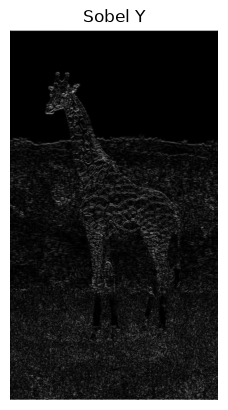

In [10]:
plt.imshow(np.abs(gy), cmap="gray")
plt.title("Sobel Y")
plt.axis("off")
plt.show()

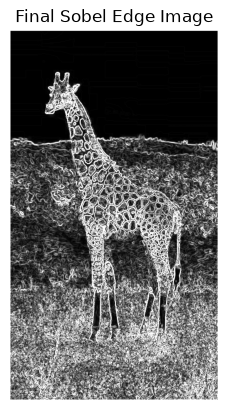

In [11]:
plt.imshow(edge_image, cmap="gray")
plt.title("Final Sobel Edge Image")
plt.axis("off")
plt.show()